# `pipeline/03_training/train_lora_two_phase_ablation.ipynb`

Canonical two-phase LoRA training notebook for **phase-scheduled batching experiments**.

This version is configured for:

- **exp_008**: `random -> grouped`
- Dataset: `dolly_small_1k`
- Base model: `flan-t5-small`

Edit only the experiment config cell if you want to reuse it for later two-phase runs.


In [10]:
# Optional if Colab env is fresh:
# !pip install -q -U transformers datasets peft accelerate sentencepiece evaluate bert-score rouge-score

Imports + Drive mount check

In [18]:
import os
import gc
import json
import math
import time
import random
from dataclasses import dataclass
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from torch.utils.data import DataLoader

from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    TrainerCallback,
)

try:
    from transformers.utils.notebook import NotebookProgressCallback
except Exception:
    NotebookProgressCallback = None

from peft import LoraConfig, TaskType, get_peft_model

# Mount Google Drive only if needed
try:
    from google.colab import drive  # type: ignore
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    else:
        print("Google Drive is already mounted.")
except Exception as e:
    print("Skipping Google Drive mount (not running in Colab or drive unavailable):", e)

Google Drive is already mounted.


## Load manifest

In [12]:
ROOT = "/content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research"
MANIFEST_PATH = f"{ROOT}/manifests/bootstrap_manifest.json"

if not os.path.exists(MANIFEST_PATH):
    raise FileNotFoundError(
        f"bootstrap_manifest.json not found at: {MANIFEST_PATH}\n"
        "Run the bootstrap notebook first."
    )

with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

DIRS = manifest["dirs"]

def _safe_makedirs(path: str) -> None:
    os.makedirs(path, exist_ok=True)

def _now_utc() -> str:
    return time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())

print("Loaded manifest created_at_utc:", manifest.get("created_at_utc"))
print("ROOT:", manifest.get("root", ROOT))
print("Experiments dir:", DIRS["experiments"])

Loaded manifest created_at_utc: 2026-03-26T00:00:00Z
ROOT: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research
Experiments dir: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments


## Experiment config (exp_008 = random -> grouped)

In [13]:
# ---------- Experiment identity ----------
EXP_ID = "exp_008_random_then_grouped_lora"
METHOD = "random_then_grouped_lora"

# ---------- Phase schedule ----------
PHASE_SCHEDULE = [
    {"phase_name": "phase_1_random", "sampler_mode": "random", "epochs": 12, "grouped_fraction": None},
    {"phase_name": "phase_2_grouped", "sampler_mode": "grouped", "epochs": 8, "grouped_fraction": None},
]

# ---------- Dataset ----------
DATASET_NAME = "dolly_small_1k"
SPLIT_NAME = "train"
INSTRUCTION_FIELD = "instruction"
CONTEXT_FIELD = "context"
RESPONSE_FIELD = "response"

# ---------- Model ----------
BASE_MODEL_DIRNAME = "flan-t5-small"
BASE_MODEL_PATH = f"{DIRS['shared_models_base']}/{BASE_MODEL_DIRNAME}"

# ---------- Retrieval assets ----------
EMBED_MODEL_DIRNAME = "all-MiniLM-L6-v2"
BUNDLE_NAME = f"{DATASET_NAME}__{EMBED_MODEL_DIRNAME}"
BUNDLE_DIR = f"{DIRS['shared_indexes_faiss']}/{BUNDLE_NAME}"

# ---------- Tokenization ----------
MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256
CACHE_TOKENIZED = True
TOKEN_CACHE_VERSION = "tok_with_rawidx_v1"

# ---------- Train/Eval split ----------
EVAL_RATIO = 0.10
SEED = 42

# ---------- Training ----------
PER_DEVICE_BATCH = 8
GRAD_ACCUM = 1
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.03
LOGGING_STEPS = 20
EVAL_STEPS = 100
SAVE_STEPS = 100
SAVE_TOTAL_LIMIT = 3

# ---------- Precision ----------
FP16 = False
BF16 = False

# ---------- LoRA ----------
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
TARGET_MODULES = ["q", "v"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

valid_sampler_modes = {"random", "grouped", "mixed"}
for phase in PHASE_SCHEDULE:
    if phase["sampler_mode"] not in valid_sampler_modes:
        raise ValueError(f"Unsupported sampler_mode: {phase['sampler_mode']}")
    if phase["sampler_mode"] == "mixed":
        gf = phase.get("grouped_fraction")
        if gf is None or not (0.0 < gf < 1.0):
            raise ValueError("mixed phase requires grouped_fraction in (0, 1)")

TOTAL_EPOCHS = sum(int(p["epochs"]) for p in PHASE_SCHEDULE)

print("EXP_ID:", EXP_ID)
print("METHOD:", METHOD)
print("TOTAL_EPOCHS:", TOTAL_EPOCHS)
print("DEVICE:", DEVICE)
print("BASE_MODEL_PATH:", BASE_MODEL_PATH)
print("BUNDLE_DIR:", BUNDLE_DIR)
print("PHASE_SCHEDULE:")
for phase in PHASE_SCHEDULE:
    print(" -", phase)

EXP_ID: exp_008_random_then_grouped_lora
METHOD: random_then_grouped_lora
TOTAL_EPOCHS: 20
DEVICE: cuda
BASE_MODEL_PATH: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/shared/models/base_models/flan-t5-small
BUNDLE_DIR: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/shared/indexes/faiss/dolly_small_1k__all-MiniLM-L6-v2
PHASE_SCHEDULE:
 - {'phase_name': 'phase_1_random', 'sampler_mode': 'random', 'epochs': 12, 'grouped_fraction': None}
 - {'phase_name': 'phase_2_grouped', 'sampler_mode': 'grouped', 'epochs': 8, 'grouped_fraction': None}


## Output paths

In [14]:
RUN_ROOT = f"{DIRS['experiments']}/{EXP_ID}"
OUT_CHECKPOINTS = f"{RUN_ROOT}/checkpoints"
OUT_LOGS = f"{RUN_ROOT}/logs"
OUT_PLOTS = f"{RUN_ROOT}/plots"
OUT_TABLES = f"{RUN_ROOT}/tables"
OUT_ADAPTER = f"{RUN_ROOT}/adapter"

RUN_MANIFEST_PATH = f"{RUN_ROOT}/run_manifest.json"
RUN_SUMMARY_PATH = f"{RUN_ROOT}/run_summary.json"
COMBINED_METRICS_JSONL_PATH = f"{OUT_LOGS}/combined_metrics.jsonl"
LOSS_PLOT_PATH = f"{OUT_PLOTS}/phase_loss_curves.png"
PHASE_COHERENCE_CSV_PATH = f"{OUT_TABLES}/phase_coherence.csv"
EXPERIMENT_CSV_PATH = f"{DIRS['experiments']}/experiment_logs.csv"

_safe_makedirs(RUN_ROOT)
_safe_makedirs(OUT_CHECKPOINTS)
_safe_makedirs(OUT_LOGS)
_safe_makedirs(OUT_PLOTS)
_safe_makedirs(OUT_TABLES)
_safe_makedirs(OUT_ADAPTER)

PHASE_DIRS = {}
for phase in PHASE_SCHEDULE:
    phase_name = phase["phase_name"]
    phase_root = f"{RUN_ROOT}/{phase_name}"
    PHASE_DIRS[phase_name] = {
        "root": phase_root,
        "checkpoints": f"{phase_root}/checkpoints",
        "metrics_jsonl": f"{phase_root}/metrics.jsonl",
    }
    _safe_makedirs(phase_root)
    _safe_makedirs(PHASE_DIRS[phase_name]["checkpoints"])

print("RUN_ROOT:", RUN_ROOT)

RUN_ROOT: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_008_random_then_grouped_lora


## Dataset load + deterministic split

In [15]:
dataset_path = f"{DIRS['shared_datasets_raw']}/{DATASET_NAME}"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")

ds = load_from_disk(dataset_path)
raw = ds[SPLIT_NAME]

required = {INSTRUCTION_FIELD, RESPONSE_FIELD}
missing = [c for c in required if c not in raw.column_names]
if missing:
    raise KeyError(f"Missing columns in dataset: {missing}. Available: {raw.column_names}")

raw = raw.map(lambda ex, idx: {"raw_idx": int(idx)}, with_indices=True)

base = raw.shuffle(seed=SEED)
n = len(base)
n_eval = max(1, int(n * EVAL_RATIO))
eval_ds = base.select(range(n_eval))
train_ds = base.select(range(n_eval, n))

def keep_example(ex: Dict[str, Any]) -> bool:
    r = ex.get(RESPONSE_FIELD)
    i = ex.get(INSTRUCTION_FIELD)
    return (r is not None and str(r).strip() != "") and (i is not None and str(i).strip() != "")

train_ds = train_ds.filter(keep_example)
eval_ds = eval_ds.filter(keep_example)

print("Rows total:", n)
print("Train:", len(train_ds), "Eval:", len(eval_ds))
print("Example raw_idx:", train_ds[0]["raw_idx"])
print("Example instruction:", train_ds[0][INSTRUCTION_FIELD][:160])

Rows total: 1000
Train: 900 Eval: 100
Example raw_idx: 797
Example instruction: Which is a species of fish? Cisco or Palo Alto


## Tokenization

In [19]:
token_cache_dir = f"{DIRS['shared_datasets_processed']}/{DATASET_NAME}__{BASE_MODEL_DIRNAME}__{TOKEN_CACHE_VERSION}"
train_tok_path = f"{token_cache_dir}/train"
eval_tok_path = f"{token_cache_dir}/eval"

def preprocess_batch(batch: Dict[str, List[Any]]) -> Dict[str, Any]:
    prompts = []
    targets = []
    ctxs = batch.get(CONTEXT_FIELD, [""] * len(batch[INSTRUCTION_FIELD]))

    for instr, ctx, resp in zip(
        batch.get(INSTRUCTION_FIELD, []),
        ctxs,
        batch.get(RESPONSE_FIELD, []),
    ):
        instr = (instr or "").strip()
        ctx = (ctx or "").strip()
        resp = (resp or "").strip()

        if ctx:
            prompt = f"### Instruction:\n{instr}\n\n### Context:\n{ctx}\n\n### Response:\n"
        else:
            prompt = f"### Instruction:\n{instr}\n\n### Response:\n"

        prompts.append(prompt)
        targets.append(resp)

    model_inputs = tokenizer(
        prompts,
        max_length=MAX_SOURCE_LEN,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

def add_raw_idx_batch(batch: Dict[str, List[Any]]) -> Dict[str, List[int]]:
    return {"raw_idx": [int(x) for x in batch["raw_idx"]]}

if CACHE_TOKENIZED and os.path.exists(train_tok_path) and os.path.exists(eval_tok_path):
    train_tok = load_from_disk(train_tok_path)
    eval_tok = load_from_disk(eval_tok_path)
    print("Loaded cached tokenized datasets.")
else:
    train_tok = train_ds.map(
        preprocess_batch,
        batched=True,
        remove_columns=train_ds.column_names,
        desc="Tokenizing train",
    )
    eval_tok = eval_ds.map(
        preprocess_batch,
        batched=True,
        remove_columns=eval_ds.column_names,
        desc="Tokenizing eval",
    )

    train_raw_idx = train_ds.map(
        add_raw_idx_batch,
        batched=True,
        remove_columns=[c for c in train_ds.column_names if c != "raw_idx"],
        desc="Extracting train raw_idx",
    )
    eval_raw_idx = eval_ds.map(
        add_raw_idx_batch,
        batched=True,
        remove_columns=[c for c in eval_ds.column_names if c != "raw_idx"],
        desc="Extracting eval raw_idx",
    )

    train_tok = train_tok.add_column("raw_idx", train_raw_idx["raw_idx"])
    eval_tok = eval_tok.add_column("raw_idx", eval_raw_idx["raw_idx"])

    if CACHE_TOKENIZED:
        _safe_makedirs(token_cache_dir)
        train_tok.save_to_disk(train_tok_path)
        eval_tok.save_to_disk(eval_tok_path)
        print("Saved tokenized datasets to cache.")

print("Train tokenized rows:", len(train_tok))
print("Eval tokenized rows:", len(eval_tok))
print("Train tokenized columns:", train_tok.column_names)

Loaded cached tokenized datasets.
Train tokenized rows: 900
Eval tokenized rows: 100
Train tokenized columns: ['raw_idx', 'input_ids', 'attention_mask', 'labels']


## Model + Tokenizer

In [20]:
if not os.path.exists(BASE_MODEL_PATH):
    raise FileNotFoundError(f"Base model path not found: {BASE_MODEL_PATH}")

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL_PATH)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=TARGET_MODULES,
    inference_mode=False,
)

model = get_peft_model(base_model, peft_config)
model.print_trainable_parameters()

if torch.cuda.is_available():
    model = model.to("cuda")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


trainable params: 688,128 || all params: 77,649,280 || trainable%: 0.8862


## Retrieval assets + Sampler

In [22]:
emb_path = f"{BUNDLE_DIR}/embeddings.npy"
neighbors_idx_path = f"{BUNDLE_DIR}/neighbors_topk_idx.npy"
neighbors_score_path = f"{BUNDLE_DIR}/neighbors_topk_scores.npy"

needs_retrieval = any(phase["sampler_mode"] in {"grouped", "mixed"} for phase in PHASE_SCHEDULE)

if needs_retrieval:
    for p in [emb_path, neighbors_idx_path, neighbors_score_path]:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Missing retrieval asset: {p}")

    X = np.load(emb_path).astype("float32")
    X = X / np.clip(np.linalg.norm(X, axis=1, keepdims=True), 1e-12, None)
    neighbors_idx = np.load(neighbors_idx_path)
    neighbors_score = np.load(neighbors_score_path)

    trainpos_to_raw = [int(x) for x in train_tok["raw_idx"]]
    raw_to_trainpos = {r: i for i, r in enumerate(trainpos_to_raw)}

    print("Embeddings shape:", X.shape)
    print("Neighbors shape:", neighbors_idx.shape)
else:
    X = None
    neighbors_idx = None
    neighbors_score = None
    trainpos_to_raw = None
    raw_to_trainpos = None


@dataclass
class RetrievalBatchSamplerConfig:
    batch_size: int
    seed: int
    mode: str
    grouped_fraction: float = 0.80
    drop_last: bool = True

    def __post_init__(self):
        if self.mode not in {"grouped", "mixed"}:
            raise ValueError(f"Unsupported sampler mode: {self.mode}")
        if self.mode == "mixed" and not (0.0 < self.grouped_fraction < 1.0):
            raise ValueError("grouped_fraction must be in (0, 1) for mixed mode.")

    @property
    def grouped_target(self) -> int:
        if self.mode == "grouped":
            return self.batch_size
        return max(1, min(self.batch_size, int(round(self.batch_size * self.grouped_fraction))))


class RetrievalBatchSampler:
    def __init__(self, trainpos_to_raw: List[int], raw_to_trainpos: Dict[int, int], neighbors_idx: np.ndarray, cfg: RetrievalBatchSamplerConfig):
        self.trainpos_to_raw = trainpos_to_raw
        self.raw_to_trainpos = raw_to_trainpos
        self.neighbors_idx = neighbors_idx
        self.cfg = cfg
        self.n = len(trainpos_to_raw)

    def __iter__(self):
        rng = random.Random(self.cfg.seed)
        anchors = list(range(self.n))
        rng.shuffle(anchors)
        all_positions = list(range(self.n))
        used_global = set()
        grouped_target = self.cfg.grouped_target
        batch_size = self.cfg.batch_size

        for a_pos in anchors:
            if a_pos in used_global:
                continue

            a_raw = self.trainpos_to_raw[a_pos]
            batch = [a_pos]
            used_in_batch = {a_pos}

            for nb_raw in self.neighbors_idx[a_raw]:
                if len(batch) >= grouped_target:
                    break
                nb_raw = int(nb_raw)
                nb_pos = self.raw_to_trainpos.get(nb_raw)
                if nb_pos is None or nb_pos in used_in_batch or nb_pos in used_global:
                    continue
                batch.append(nb_pos)
                used_in_batch.add(nb_pos)

            if self.cfg.mode == "mixed" and len(batch) < batch_size:
                candidates = [p for p in all_positions if p not in used_in_batch and p not in used_global]
                rng.shuffle(candidates)
                needed = batch_size - len(batch)
                for p in candidates[:needed]:
                    batch.append(p)
                    used_in_batch.add(p)

            if len(batch) == batch_size:
                for p in batch:
                    used_global.add(p)
                yield batch
            elif not self.cfg.drop_last and len(batch) > 0:
                for p in batch:
                    used_global.add(p)
                yield batch

    def __len__(self):
        return self.n // self.cfg.batch_size


def build_train_batch_sampler(
    sampler_mode: str,
    batch_size: int,
    seed: int,
    trainpos_to_raw: Optional[List[int]],
    raw_to_trainpos: Optional[Dict[int, int]],
    neighbors_idx: Optional[np.ndarray],
    grouped_fraction: Optional[float] = None,
):
    if sampler_mode == "random":
        return None

    cfg = RetrievalBatchSamplerConfig(
        batch_size=batch_size,
        seed=seed,
        mode=sampler_mode,
        grouped_fraction=0.80 if grouped_fraction is None else grouped_fraction,
        drop_last=True,
    )

    return RetrievalBatchSampler(
        trainpos_to_raw=trainpos_to_raw,
        raw_to_trainpos=raw_to_trainpos,
        neighbors_idx=neighbors_idx,
        cfg=cfg,
    )


def compute_coherence_for_batch(batch_trainpos: List[int]) -> Optional[float]:
    if X is None:
        return None
    a_pos = batch_trainpos[0]
    a_raw = trainpos_to_raw[a_pos]
    sims = [float(np.dot(X[a_raw], X[trainpos_to_raw[p]])) for p in batch_trainpos]
    return float(sum(sims) / len(sims))


for phase in PHASE_SCHEDULE:
    sampler = build_train_batch_sampler(
        sampler_mode=phase["sampler_mode"],
        batch_size=PER_DEVICE_BATCH,
        seed=SEED,
        trainpos_to_raw=trainpos_to_raw,
        raw_to_trainpos=raw_to_trainpos,
        neighbors_idx=neighbors_idx,
        grouped_fraction=phase.get("grouped_fraction"),
    )
    print(f"Phase {phase['phase_name']} -> custom sampler enabled:", sampler is not None)
    if sampler is not None:
        preview = []
        for i, b in enumerate(sampler):
            preview.append(b)
            if i >= 1:
                break
        print("  example batches:", preview)
        print("  coherence:", [compute_coherence_for_batch(b) for b in preview])

Embeddings shape: (1000, 384)
Neighbors shape: (1000, 32)
Phase phase_1_random -> custom sampler enabled: False
Phase phase_2_grouped -> custom sampler enabled: True
  example batches: [[92, 723, 487, 801, 148, 195, 721, 894], [877, 236, 88, 434, 586, 367, 580, 321]]
  coherence: [0.43777020648121834, 0.33897858671844006]


## Train helpers

In [23]:
class JsonlLoggerCallback(TrainerCallback):
    def __init__(self, path: str, phase_name: str):
        self.path = path
        self.phase_name = phase_name
        _safe_makedirs(os.path.dirname(self.path))
        if os.path.exists(self.path):
            os.remove(self.path)

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        row = {
            "phase_name": self.phase_name,
            "step": int(state.global_step),
            "epoch": float(state.epoch or 0.0),
        }
        row.update({k: v for k, v in logs.items() if isinstance(v, (int, float))})
        with open(self.path, "a", encoding="utf-8") as f:
            f.write(json.dumps(row) + "\n")


class CustomBatchSeq2SeqTrainer(Seq2SeqTrainer):
    def __init__(self, *args, train_batch_sampler=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._train_batch_sampler = train_batch_sampler

    def get_train_dataloader(self):
        if self.train_dataset is None:
            raise ValueError("Trainer: training requires a train_dataset.")

        if self._train_batch_sampler is None:
            return super().get_train_dataloader()

        return DataLoader(
            self.train_dataset,
            batch_sampler=self._train_batch_sampler,
            collate_fn=self.data_collator,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )


data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
)


def remove_notebook_progress_callback(trainer):
    if NotebookProgressCallback is None:
        return
    for cb in list(trainer.callback_handler.callbacks):
        if cb.__class__.__name__ == "NotebookProgressCallback":
            trainer.remove_callback(cb.__class__)


def read_jsonl_df(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        return pd.DataFrame()
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def build_training_args(epochs: int, output_dir: str) -> Seq2SeqTrainingArguments:
    steps_per_epoch = math.ceil(len(train_tok) / (PER_DEVICE_BATCH * GRAD_ACCUM))
    max_steps = steps_per_epoch * epochs
    warmup_steps = max(1, int(max_steps * WARMUP_RATIO))

    return Seq2SeqTrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=PER_DEVICE_BATCH,
        per_device_eval_batch_size=PER_DEVICE_BATCH,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=warmup_steps,
        logging_steps=LOGGING_STEPS,
        eval_strategy="steps",
        eval_steps=EVAL_STEPS,
        save_strategy="steps",
        save_steps=SAVE_STEPS,
        save_total_limit=SAVE_TOTAL_LIMIT,
        predict_with_generate=False,
        fp16=FP16,
        bf16=BF16,
        dataloader_pin_memory=torch.cuda.is_available(),
        report_to=[],
        seed=SEED,
        data_seed=SEED,
        load_best_model_at_end=False,
    )


def build_phase_trainer(phase: Dict[str, Any]):
    phase_name = phase["phase_name"]
    sampler_mode = phase["sampler_mode"]
    grouped_fraction = phase.get("grouped_fraction")
    epochs = int(phase["epochs"])

    phase_sampler = build_train_batch_sampler(
        sampler_mode=sampler_mode,
        batch_size=PER_DEVICE_BATCH,
        seed=SEED,
        trainpos_to_raw=trainpos_to_raw,
        raw_to_trainpos=raw_to_trainpos,
        neighbors_idx=neighbors_idx,
        grouped_fraction=grouped_fraction,
    )

    phase_args = build_training_args(
        epochs=epochs,
        output_dir=PHASE_DIRS[phase_name]["checkpoints"],
    )

    trainer = CustomBatchSeq2SeqTrainer(
        model=model,
        args=phase_args,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        data_collator=data_collator,
        callbacks=[JsonlLoggerCallback(PHASE_DIRS[phase_name]["metrics_jsonl"], phase_name=phase_name)],
        train_batch_sampler=phase_sampler,
    )
    remove_notebook_progress_callback(trainer)
    return trainer

## Train Phases

In [24]:
phase_results = []

for phase in PHASE_SCHEDULE:
    phase_name = phase["phase_name"]
    print("=" * 80)
    print(f"Starting {phase_name} | sampler={phase['sampler_mode']} | epochs={phase['epochs']}")
    if phase["sampler_mode"] == "mixed":
        print("grouped_fraction:", phase.get("grouped_fraction"))

    trainer = build_phase_trainer(phase)
    train_result = trainer.train()

    remove_notebook_progress_callback(trainer)
    eval_metrics = trainer.evaluate(eval_dataset=eval_tok)

    phase_results.append({
        "phase_name": phase_name,
        "sampler_mode": phase["sampler_mode"],
        "grouped_fraction": phase.get("grouped_fraction"),
        "epochs": int(phase["epochs"]),
        "train_metrics": train_result.metrics,
        "eval_metrics": eval_metrics,
        "metrics_jsonl": PHASE_DIRS[phase_name]["metrics_jsonl"],
    })

    print("Train metrics:", train_result.metrics)
    print("Eval metrics:", eval_metrics)

    del trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Completed phases:", [x["phase_name"] for x in phase_results])

Starting phase_1_random | sampler=random | epochs=12
Train metrics: {'train_runtime': 179.2514, 'train_samples_per_second': 60.251, 'train_steps_per_second': 7.565, 'total_flos': 893643825807360.0, 'train_loss': 9.121200235192402, 'epoch': 12.0}
Eval metrics: {'eval_loss': 8.687149047851562, 'eval_runtime': 0.6373, 'eval_samples_per_second': 156.92, 'eval_steps_per_second': 20.4, 'epoch': 12.0}
Starting phase_2_grouped | sampler=grouped | epochs=8
Train metrics: {'train_runtime': 101.4092, 'train_samples_per_second': 70.999, 'train_steps_per_second': 8.835, 'total_flos': 458425311559680.0, 'train_loss': 8.845415462147106, 'epoch': 7.883928571428571}
Eval metrics: {'eval_loss': 8.545308113098145, 'eval_runtime': 0.6439, 'eval_samples_per_second': 155.312, 'eval_steps_per_second': 20.191, 'epoch': 7.883928571428571}
Completed phases: ['phase_1_random', 'phase_2_grouped']


## Save adapter +summarize

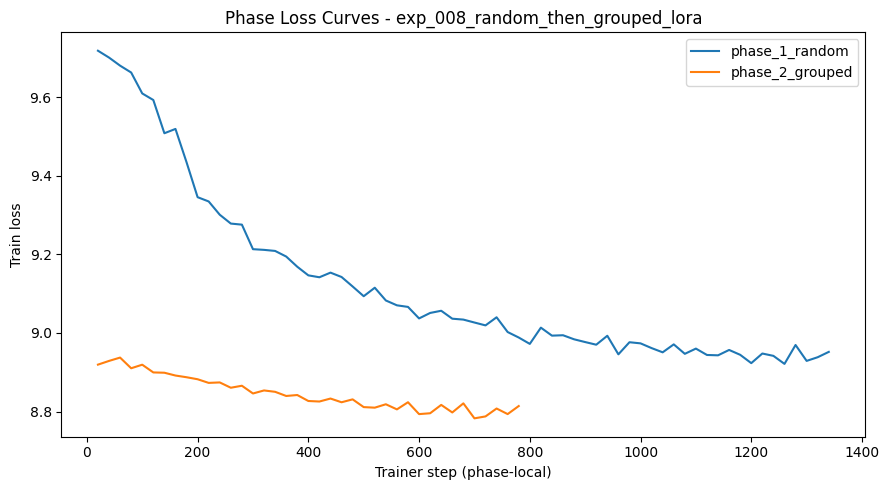

Saved: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_008_random_then_grouped_lora/plots/phase_loss_curves.png
Wrote: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_008_random_then_grouped_lora/run_summary.json
{
  "exp_id": "exp_008_random_then_grouped_lora",
  "method": "random_then_grouped_lora",
  "completed_at_utc": "2026-04-01T17:48:56Z",
  "dataset_name": "dolly_small_1k",
  "base_model": "flan-t5-small",
  "train_size": 900,
  "eval_size": 100,
  "final_train_loss": 8.814036560058593,
  "final_eval_loss": 8.545308113098145,
  "phase_schedule": [
    {
      "phase_name": "phase_1_random",
      "sampler_mode": "random",
      "epochs": 12,
      "grouped_fraction": null
    },
    {
      "phase_name": "phase_2_grouped",
      "sampler_mode": "grouped",
      "epochs": 8,
      "grouped_fraction": null
    }
  ],
  "phase_results": [
    {
      "phase_name": "phase_1_random",
      "sampler_mode": "rando

In [25]:
model.save_pretrained(OUT_ADAPTER)
tokenizer.save_pretrained(OUT_ADAPTER)

combined_rows = []
for phase in PHASE_SCHEDULE:
    phase_name = phase["phase_name"]
    phase_df = read_jsonl_df(PHASE_DIRS[phase_name]["metrics_jsonl"])
    if not phase_df.empty:
        phase_df = phase_df.copy()
        phase_df["phase_name"] = phase_name
        combined_rows.extend(phase_df.to_dict(orient="records"))

combined_metrics_df = pd.DataFrame(combined_rows)

if not combined_metrics_df.empty:
    with open(COMBINED_METRICS_JSONL_PATH, "w", encoding="utf-8") as f:
        for row in combined_rows:
            f.write(json.dumps(row) + "\n")

loss_df = pd.DataFrame(columns=["phase_name", "step", "loss"])
if not combined_metrics_df.empty and "loss" in combined_metrics_df.columns:
    loss_df = combined_metrics_df[combined_metrics_df["loss"].notna()][["phase_name", "step", "loss"]].copy()
    loss_df = loss_df.reset_index(drop=True)

coherence_stats = []
for phase in PHASE_SCHEDULE:
    phase_name = phase["phase_name"]
    sampler_mode = phase["sampler_mode"]
    grouped_fraction = phase.get("grouped_fraction")

    if sampler_mode == "random":
        coherence_stats.append({
            "phase_name": phase_name,
            "sampler_mode": sampler_mode,
            "grouped_fraction": grouped_fraction,
            "coherence_mean": None,
            "coherence_std": None,
            "coherence_n_batches_sampled": 0,
        })
        continue

    sampler_for_stats = build_train_batch_sampler(
        sampler_mode=sampler_mode,
        batch_size=PER_DEVICE_BATCH,
        seed=SEED,
        trainpos_to_raw=trainpos_to_raw,
        raw_to_trainpos=raw_to_trainpos,
        neighbors_idx=neighbors_idx,
        grouped_fraction=grouped_fraction,
    )

    cohs = []
    for i, batch in enumerate(sampler_for_stats):
        cohs.append(compute_coherence_for_batch(batch))
        if i >= 500:
            break

    coherence_stats.append({
        "phase_name": phase_name,
        "sampler_mode": sampler_mode,
        "grouped_fraction": grouped_fraction,
        "coherence_mean": float(np.mean(cohs)) if cohs else None,
        "coherence_std": float(np.std(cohs)) if cohs else None,
        "coherence_n_batches_sampled": len(cohs),
    })

coherence_df = pd.DataFrame(coherence_stats)
coherence_df.to_csv(PHASE_COHERENCE_CSV_PATH, index=False)

if not loss_df.empty:
    plt.figure(figsize=(9, 5))
    for phase_name, phase_loss_df in loss_df.groupby("phase_name"):
        plt.plot(phase_loss_df["step"], phase_loss_df["loss"], label=phase_name)
    plt.xlabel("Trainer step (phase-local)")
    plt.ylabel("Train loss")
    plt.title(f"Phase Loss Curves - {EXP_ID}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(LOSS_PLOT_PATH, dpi=150)
    plt.show()
    print("Saved:", LOSS_PLOT_PATH)

final_eval_metrics = phase_results[-1]["eval_metrics"] if phase_results else {}
final_phase_name = phase_results[-1]["phase_name"] if phase_results else None
final_train_loss = None
if not loss_df.empty:
    final_phase_loss_df = loss_df[loss_df["phase_name"] == final_phase_name]
    if not final_phase_loss_df.empty:
        final_train_loss = float(final_phase_loss_df["loss"].iloc[-1])

run_summary = {
    "exp_id": EXP_ID,
    "method": METHOD,
    "completed_at_utc": _now_utc(),
    "dataset_name": DATASET_NAME,
    "base_model": BASE_MODEL_DIRNAME,
    "train_size": len(train_tok),
    "eval_size": len(eval_tok),
    "final_train_loss": final_train_loss,
    "final_eval_loss": float(final_eval_metrics["eval_loss"]) if "eval_loss" in final_eval_metrics else None,
    "phase_schedule": PHASE_SCHEDULE,
    "phase_results": phase_results,
    "coherence_by_phase": coherence_stats,
    "paths": {
        "run_manifest": RUN_MANIFEST_PATH,
        "adapter": OUT_ADAPTER,
        "metrics_jsonl": COMBINED_METRICS_JSONL_PATH,
        "loss_plot": LOSS_PLOT_PATH,
        "phase_coherence_csv": PHASE_COHERENCE_CSV_PATH,
    },
}

with open(RUN_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2)

print("Wrote:", RUN_SUMMARY_PATH)
print(json.dumps(run_summary, indent=2)[:5000])

## Append light weight experiment log

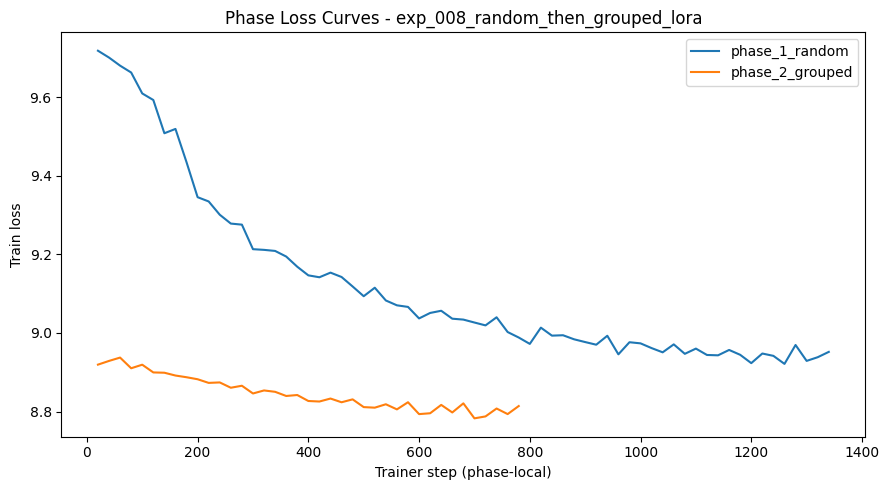

Saved: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_008_random_then_grouped_lora/plots/phase_loss_curves.png
Wrote: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/experiments/exp_008_random_then_grouped_lora/run_summary.json
{
  "exp_id": "exp_008_random_then_grouped_lora",
  "method": "random_then_grouped_lora",
  "completed_at_utc": "2026-04-01T17:48:57Z",
  "dataset_name": "dolly_small_1k",
  "base_model": "flan-t5-small",
  "train_size": 900,
  "eval_size": 100,
  "final_train_loss": 8.814036560058593,
  "final_eval_loss": 8.545308113098145,
  "phase_schedule": [
    {
      "phase_name": "phase_1_random",
      "sampler_mode": "random",
      "epochs": 12,
      "grouped_fraction": null
    },
    {
      "phase_name": "phase_2_grouped",
      "sampler_mode": "grouped",
      "epochs": 8,
      "grouped_fraction": null
    }
  ],
  "phase_results": [
    {
      "phase_name": "phase_1_random",
      "sampler_mode": "rando

In [26]:
model.save_pretrained(OUT_ADAPTER)
tokenizer.save_pretrained(OUT_ADAPTER)

combined_rows = []
for phase in PHASE_SCHEDULE:
    phase_name = phase["phase_name"]
    phase_df = read_jsonl_df(PHASE_DIRS[phase_name]["metrics_jsonl"])
    if not phase_df.empty:
        phase_df = phase_df.copy()
        phase_df["phase_name"] = phase_name
        combined_rows.extend(phase_df.to_dict(orient="records"))

combined_metrics_df = pd.DataFrame(combined_rows)

if not combined_metrics_df.empty:
    with open(COMBINED_METRICS_JSONL_PATH, "w", encoding="utf-8") as f:
        for row in combined_rows:
            f.write(json.dumps(row) + "\n")

loss_df = pd.DataFrame(columns=["phase_name", "step", "loss"])
if not combined_metrics_df.empty and "loss" in combined_metrics_df.columns:
    loss_df = combined_metrics_df[combined_metrics_df["loss"].notna()][["phase_name", "step", "loss"]].copy()
    loss_df = loss_df.reset_index(drop=True)

coherence_stats = []
for phase in PHASE_SCHEDULE:
    phase_name = phase["phase_name"]
    sampler_mode = phase["sampler_mode"]
    grouped_fraction = phase.get("grouped_fraction")

    if sampler_mode == "random":
        coherence_stats.append({
            "phase_name": phase_name,
            "sampler_mode": sampler_mode,
            "grouped_fraction": grouped_fraction,
            "coherence_mean": None,
            "coherence_std": None,
            "coherence_n_batches_sampled": 0,
        })
        continue

    sampler_for_stats = build_train_batch_sampler(
        sampler_mode=sampler_mode,
        batch_size=PER_DEVICE_BATCH,
        seed=SEED,
        trainpos_to_raw=trainpos_to_raw,
        raw_to_trainpos=raw_to_trainpos,
        neighbors_idx=neighbors_idx,
        grouped_fraction=grouped_fraction,
    )

    cohs = []
    for i, batch in enumerate(sampler_for_stats):
        cohs.append(compute_coherence_for_batch(batch))
        if i >= 500:
            break

    coherence_stats.append({
        "phase_name": phase_name,
        "sampler_mode": sampler_mode,
        "grouped_fraction": grouped_fraction,
        "coherence_mean": float(np.mean(cohs)) if cohs else None,
        "coherence_std": float(np.std(cohs)) if cohs else None,
        "coherence_n_batches_sampled": len(cohs),
    })

coherence_df = pd.DataFrame(coherence_stats)
coherence_df.to_csv(PHASE_COHERENCE_CSV_PATH, index=False)

if not loss_df.empty:
    plt.figure(figsize=(9, 5))
    for phase_name, phase_loss_df in loss_df.groupby("phase_name"):
        plt.plot(phase_loss_df["step"], phase_loss_df["loss"], label=phase_name)
    plt.xlabel("Trainer step (phase-local)")
    plt.ylabel("Train loss")
    plt.title(f"Phase Loss Curves - {EXP_ID}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(LOSS_PLOT_PATH, dpi=150)
    plt.show()
    print("Saved:", LOSS_PLOT_PATH)

final_eval_metrics = phase_results[-1]["eval_metrics"] if phase_results else {}
final_phase_name = phase_results[-1]["phase_name"] if phase_results else None
final_train_loss = None
if not loss_df.empty:
    final_phase_loss_df = loss_df[loss_df["phase_name"] == final_phase_name]
    if not final_phase_loss_df.empty:
        final_train_loss = float(final_phase_loss_df["loss"].iloc[-1])

run_summary = {
    "exp_id": EXP_ID,
    "method": METHOD,
    "completed_at_utc": _now_utc(),
    "dataset_name": DATASET_NAME,
    "base_model": BASE_MODEL_DIRNAME,
    "train_size": len(train_tok),
    "eval_size": len(eval_tok),
    "final_train_loss": final_train_loss,
    "final_eval_loss": float(final_eval_metrics["eval_loss"]) if "eval_loss" in final_eval_metrics else None,
    "phase_schedule": PHASE_SCHEDULE,
    "phase_results": phase_results,
    "coherence_by_phase": coherence_stats,
    "paths": {
        "run_manifest": RUN_MANIFEST_PATH,
        "adapter": OUT_ADAPTER,
        "metrics_jsonl": COMBINED_METRICS_JSONL_PATH,
        "loss_plot": LOSS_PLOT_PATH,
        "phase_coherence_csv": PHASE_COHERENCE_CSV_PATH,
    },
}

with open(RUN_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2)

print("Wrote:", RUN_SUMMARY_PATH)
print(json.dumps(run_summary, indent=2)[:5000])